# Module 4 - Machine Learning Basics

## Iris Flower Classification

### Codomax Data Scientist Internship

This project demonstrates the basics of Machine Learning using Python and Scikit-learn.

### Objective

The objective of this project is to build a Machine Learning classification model that can predict the species of an Iris flower based on its measurements.

### Tasks Covered

- Loading the Iris dataset
- Exploring the dataset
- Visualizing the data
- Splitting data into training and testing sets
- Training a Machine Learning model
- Making predictions
- Evaluating model performance

In [2]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load the Iris dataset

iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target/species column
df["species"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Dataset Exploration

In [5]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
# Display basic statistical information

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Data Visualization

Visualization helps us understand the relationship between the different Iris flower measurements and species.

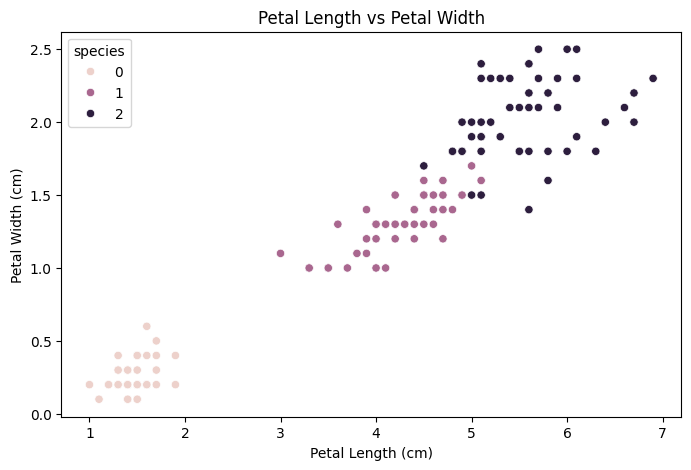

In [8]:
# Visualize the relationship between petal length and petal width

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

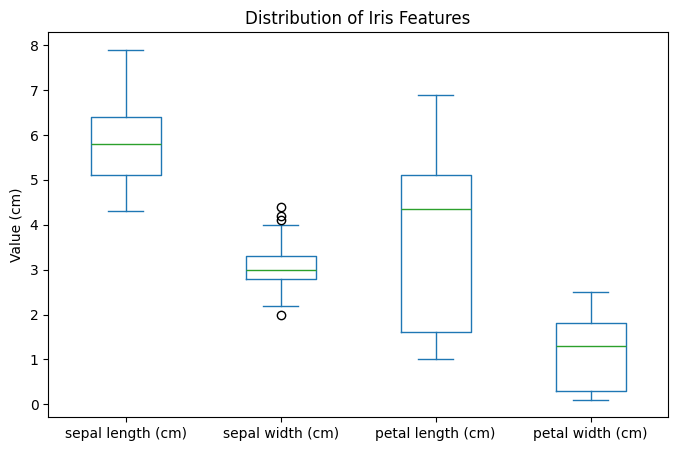

In [9]:
# Visualize the distribution of Iris features

df.iloc[:, :4].plot(
    kind="box",
    figsize=(8, 5)
)

plt.title("Distribution of Iris Features")
plt.ylabel("Value (cm)")
plt.show()

## Preparing Data for Machine Learning

The dataset is divided into:

- **Features (X):** Flower measurements
- **Target (y):** Iris flower species

In [10]:
# Separate features and target

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


## Train-Test Split

We split the dataset into two parts:

- **Training data:** Used to teach the model.
- **Testing data:** Used to check how well the model performs on unseen data.

In [11]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


## Building the Machine Learning Model

We will use the **K-Nearest Neighbors (KNN)** classification algorithm.

KNN predicts the species of a new flower by looking at the most similar flowers in the training data.

In [12]:
# Create the KNN model

model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## Making Predictions

The trained model is now used to predict the species of flowers in the test dataset.

In [13]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predicted classes:")
print(y_pred)

Predicted classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


## Model Evaluation

Accuracy tells us how many predictions the model made correctly out of all the test samples.

In [14]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


## Confusion Matrix

A confusion matrix shows how many samples were classified correctly and incorrectly for each Iris species.

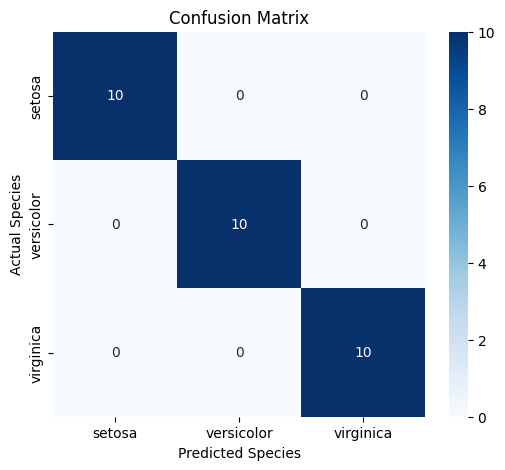

In [15]:
# Create and display the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

## Classification Report

The classification report provides detailed performance metrics such as:

- Precision
- Recall
- F1-score
- Support

In [16]:
# Display the classification report

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Predicting a New Iris Flower

We can provide measurements of a new Iris flower and use our trained model to predict its species.

In [17]:
# Example measurements of a new Iris flower
# [sepal length, sepal width, petal length, petal width]

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

predicted_species = iris.target_names[prediction[0]]

print("Predicted Iris species:", predicted_species)

Predicted Iris species: setosa


## Conclusion

In this project, we built a Machine Learning classification model using the Iris dataset and Scikit-learn.

We successfully:

- Loaded and explored the Iris dataset.
- Visualized the flower measurements.
- Split the data into training and testing sets.
- Trained a K-Nearest Neighbors (KNN) classification model.
- Made predictions on test data.
- Evaluated the model using accuracy, confusion matrix, and classification report.
- Tested the model with a new flower sample.

The project demonstrates the basic Machine Learning workflow of preparing data, training a model, making predictions, and evaluating its performance.